# PHQ-8 Depression Detection - Mental-RoBERTa + LSTM + Attention Pooling + MLP (Classification)

This notebook keeps the original frozen Mental-RoBERTa chunk-feature pipeline and adds an LSTM over the chunk sequence before attention pooling for participant-level classification.


## 1. Install Dependencies

In [15]:
!pip install transformers tqdm pandas numpy scikit-learn matplotlib --quiet
print("All packages ready.")

All packages ready.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports & Configuration

In [16]:
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
from torch.optim import Adam

import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report
)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm

print("Imports successful.")

Imports successful.


In [17]:
# --- Paths ---
BASE_DIR        = Path("..")
DATASET_DIR     = BASE_DIR / "dataset"
TRANSCRIPT_DIR  = DATASET_DIR / "cleaned"
PROCESSED_DIR   = BASE_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = DATASET_DIR / "train_split_Depression_AVEC2017.csv"
DEV_CSV   = DATASET_DIR / "dev_split_Depression_AVEC2017.csv"
TEST_CSV  = DATASET_DIR / "full_test_split.csv"

FEATURE_CACHE = PROCESSED_DIR / "mental_roberta_features_cls.npz"

MENTAL_ROBERTA_MODEL_ID = str(Path("models") / "mental_roberta")  # local model folder inside experiments/

SAVE_DIR = BASE_DIR / "experiments" / "best_model" / "mental_roberta_lstm_cls"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# --- Device ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device   : {DEVICE}")
print(f"Feature cache  : {FEATURE_CACHE.resolve()}")
print(f"Checkpoint dir : {SAVE_DIR.resolve()}")

Using device   : cuda
Feature cache  : C:\Users\edgar\OneDrive\Documents\Term_8\Deep_learning\Project\phq8_depression_detection\processed\mental_roberta_features_cls.npz
Checkpoint dir : C:\Users\edgar\OneDrive\Documents\Term_8\Deep_learning\Project\phq8_depression_detection\experiments\best_model\mental_roberta_lstm_cls


## 3. Load Label Files

Binary labels:
- `PHQ8_Binary` in train/dev CSVs â€” 1 if PHQ-8 â‰¥ 10, else 0
- `PHQ_Binary` in test CSV (same threshold, different column name)

In [18]:
train_df = pd.read_csv(TRAIN_CSV)[["Participant_ID", "PHQ8_Binary"]]
dev_df   = pd.read_csv(DEV_CSV)[["Participant_ID", "PHQ8_Binary"]]
test_df  = pd.read_csv(TEST_CSV)[["Participant_ID", "PHQ_Binary"]].rename(
    columns={"PHQ_Binary": "PHQ8_Binary"}
)

train_labels = dict(zip(train_df.Participant_ID, train_df.PHQ8_Binary))
dev_labels   = dict(zip(dev_df.Participant_ID,   dev_df.PHQ8_Binary))
test_labels  = dict(zip(test_df.Participant_ID,  test_df.PHQ8_Binary))

pid_to_label = {**train_labels, **dev_labels, **test_labels}
pid_to_split = (
    {pid: "train" for pid in train_labels}
    | {pid: "dev"   for pid in dev_labels}
    | {pid: "test"  for pid in test_labels}
)

for name, labels in [("Train", train_labels), ("Dev", dev_labels), ("Test", test_labels)]:
    dep  = sum(labels.values())
    ctrl = len(labels) - dep
    print(f"{name:5s}: {len(labels):3d} participants  "
          f"depressed: {dep}  control: {ctrl}")

Train: 107 participants  depressed: 30  control: 77
Dev  :  35 participants  depressed: 12  control: 23
Test :  47 participants  depressed: 14  control: 33


## 4. Feature Extraction

Transcripts in `dataset/transcripts/` are chunked into **200-token windows** with a **50-token overlap**.
Each chunk is passed through frozen Mental-RoBERTa and the **[CLS] token embedding** (first token `<s>`) is taken -> **768-dim feature vector**.

Features are saved to `processed/mental_roberta_features_cls.npz` and reloaded on subsequent runs.
The new LSTM operates on the cached chunk sequence, so feature extraction stays unchanged.


In [19]:
CHUNK_TOKENS   = 200   # tokens per chunk (excluding special tokens)
OVERLAP_TOKENS = 50    # overlapping tokens between consecutive chunks
STRIDE         = CHUNK_TOKENS - OVERLAP_TOKENS

if FEATURE_CACHE.exists():
    print(f"Feature cache found at {FEATURE_CACHE.name} â€” skipping extraction.")
else:
    print(f"Extracting RoBERTa features â†’ {FEATURE_CACHE.name}")
    print(f"  Model      : {MENTAL_ROBERTA_MODEL_ID}")
    print(f"  Chunk size : {CHUNK_TOKENS} tokens   Overlap : {OVERLAP_TOKENS} tokens")

    from transformers import RobertaModel, RobertaTokenizerFast

    tokenizer = RobertaTokenizerFast.from_pretrained(MENTAL_ROBERTA_MODEL_ID)
    roberta   = RobertaModel.from_pretrained(MENTAL_ROBERTA_MODEL_ID)
    roberta.eval().to(DEVICE)
    for param in roberta.parameters():
        param.requires_grad = False
    print("RoBERTa loaded and frozen.")

    all_feats, all_bin_labels, all_pids, all_splits = [], [], [], []

    transcript_files = sorted(TRANSCRIPT_DIR.glob("*_P.txt"))
    print(f"\nProcessing {len(transcript_files)} transcript files ...")

    for txt_path in tqdm(transcript_files):
        pid = int(txt_path.stem.split("_")[0])
        if pid not in pid_to_label:
            continue

        split = pid_to_split[pid]
        label = pid_to_label[pid]

        text = txt_path.read_text(encoding="utf-8").strip()
        if not text:
            continue

        # Tokenize full transcript (no special tokens yet)
        token_ids = tokenizer.encode(text, add_special_tokens=False)

        # Sliding-window chunking over token IDs
        starts = list(range(0, max(1, len(token_ids) - CHUNK_TOKENS + 1), STRIDE))
        if not starts:
            starts = [0]

        for start in starts:
            chunk_ids = token_ids[start : start + CHUNK_TOKENS]

            # RoBERTa special tokens: <s> (cls) ... </s> (sep)
            input_ids      = [tokenizer.cls_token_id] + chunk_ids + [tokenizer.sep_token_id]
            attention_mask = [1] * len(input_ids)

            input_ids_t = torch.tensor([input_ids],      device=DEVICE)
            attn_mask_t = torch.tensor([attention_mask], device=DEVICE)

            with torch.no_grad():
                outputs = roberta(
                    input_ids=input_ids_t,
                    attention_mask=attn_mask_t,
                )
            # [CLS] embedding â€” first token of last hidden state
            feat = outputs.last_hidden_state[0, 0].cpu().numpy()  # (768,)

            all_feats.append(feat)
            all_bin_labels.append(label)
            all_pids.append(pid)
            all_splits.append(split.encode())

    np.savez_compressed(
        FEATURE_CACHE,
        feats         = np.array(all_feats,      dtype=np.float32),
        binary_labels = np.array(all_bin_labels, dtype=np.int32),
        pids          = np.array(all_pids,        dtype=np.int32),
        splits        = np.array(all_splits),
    )
    print(f"\nSaved {len(all_feats):,} chunk features at {FEATURE_CACHE}")

    del roberta, tokenizer
    torch.cuda.empty_cache()

Feature cache found at mental_roberta_features_cls.npz â€” skipping extraction.


## 5. Build Participant-Level Dataset

Load the cached features and group chunks by participant in chunk order.
The LSTM models temporal context across chunk embeddings, then attention pooling learns which encoded chunks matter most.


In [20]:
print(f"Loading features from {FEATURE_CACHE.name} ...")
cache           = np.load(FEATURE_CACHE, allow_pickle=False)
all_feats_np    = cache["feats"]          # (N, 768)
all_labels_np   = cache["binary_labels"]  # (N,)
all_pids_np     = cache["pids"]           # (N,)
all_splits_np   = cache["splits"]         # (N,)  byte strings

in_memory = {
    "train": defaultdict(lambda: {"feats": [], "label": None}),
    "dev":   defaultdict(lambda: {"feats": [], "label": None}),
    "test":  defaultdict(lambda: {"feats": [], "label": None}),
}

for feat, lbl, pid, split_b in zip(
    all_feats_np, all_labels_np, all_pids_np, all_splits_np
):
    split = split_b.decode()
    pid   = int(pid)
    in_memory[split][pid]["feats"].append(feat)
    in_memory[split][pid]["label"] = int(lbl)

splits_list = {s: list(in_memory[s].items()) for s in ("train", "dev", "test")}

print(f"\n{'Split':10s}  {'Participants':>12}  {'Chunks':>8}  {'Depressed':>9}  {'Control':>7}")
print("-" * 52)
for s, name in [("train", "train"), ("dev", "validation"), ("test", "test")]:
    n_chunks = sum(len(d["feats"]) for _, d in splits_list[s])
    n_dep    = sum(d["label"] for _, d in splits_list[s])
    n_ctrl   = len(splits_list[s]) - n_dep
    print(f"{name:10s}  {len(splits_list[s]):12d}  {n_chunks:8,}  {n_dep:9d}  {n_ctrl:7d}")

Loading features from mental_roberta_features_cls.npz ...

Split       Participants    Chunks  Depressed  Control
----------------------------------------------------
train                107       989         30       77
validation            35       354         12       23
test                  47       519         14       33


## 6. Training Configuration

In [35]:
# --- Model hyper-parameters ---
MENTAL_ROBERTA_DIM = 768
LSTM_HIDDEN        = 128
LSTM_LAYERS        = 1
LSTM_BIDIRECTIONAL = False
MLP_HIDDEN         = 64
DROPOUT            = 0.5

# --- Training hyper-parameters ---
PARTICIPANT_BATCH_SIZE  = 16
NUM_EPOCHS              = 1000
LEARNING_RATE           = 2e-4
WEIGHT_DECAY            = 1e-4
EARLY_STOPPING_PATIENCE = 100
CHECKPOINT_FREQ         = 50
GRAD_CLIP_NORM          = 1.0

LSTM_OUT_DIM = LSTM_HIDDEN * (2 if LSTM_BIDIRECTIONAL else 1)

print("Training configuration:")
print(f"  RoBERTa feature dim    : {MENTAL_ROBERTA_DIM}")
print(f"  LSTM hidden dim        : {LSTM_HIDDEN}")
print(f"  LSTM layers            : {LSTM_LAYERS}")
print(f"  LSTM bidirectional     : {LSTM_BIDIRECTIONAL}")
print(f"  LSTM output dim        : {LSTM_OUT_DIM}")
print(f"  MLP hidden dim         : {MLP_HIDDEN}")
print(f"  Dropout                : {DROPOUT}")
print(f"  Participant batch size : {PARTICIPANT_BATCH_SIZE}")
print(f"  Epochs                 : {NUM_EPOCHS}")
print(f"  Learning rate          : {LEARNING_RATE}")
print(f"  Weight decay           : {WEIGHT_DECAY}")
print(f"  Early stopping         : {EARLY_STOPPING_PATIENCE} epochs patience")
print(f"  Grad clip norm         : {GRAD_CLIP_NORM}")


Training configuration:
  RoBERTa feature dim    : 768
  LSTM hidden dim        : 128
  LSTM layers            : 1
  LSTM bidirectional     : False
  LSTM output dim        : 128
  MLP hidden dim         : 64
  Dropout                : 0.5
  Participant batch size : 16
  Epochs                 : 1000
  Learning rate          : 0.0002
  Weight decay           : 0.0001
  Early stopping         : 100 epochs patience
  Grad clip norm         : 1.0


## 7. Model - RoBERTa LSTM Attention Pooling + MLP Classifier

```
Input  : (T, 768)  [CLS] chunk embeddings for one participant
         LSTM(768, 256, bidirectional=True) -> (T, 512)
         Linear(512, 1) + softmax over T
         attention-weighted sum -> (512,)   [learned chunk importance after sequence encoding]
         LayerNorm(512)
         Linear(512, 128) + ReLU
         Dropout(0.3)
         Linear(128, 1)
Output : scalar logit  (sigmoid -> probability of depression)
```


In [36]:
class MentalRoBERTaLSTMAttentionMLPClassifier(nn.Module):
    """
    LSTM encoder + attention pooling + LayerNorm + MLP binary classifier
    on top of frozen Mental-RoBERTa [CLS] chunk features.

    Input  : (T, 768) chunk embeddings for one participant
    Output : scalar logit positive = depressed, negative = control
    """
    def __init__(
        self,
        input_dim: int = MENTAL_ROBERTA_DIM,
        lstm_hidden: int = LSTM_HIDDEN,
        lstm_layers: int = LSTM_LAYERS,
        bidirectional: bool = LSTM_BIDIRECTIONAL,
        hidden_dim: int = MLP_HIDDEN,
        dropout: float = DROPOUT,
    ):
        super().__init__()
        self.lstm_out_dim = lstm_hidden * (2 if bidirectional else 1)
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )
        self.attention = nn.Linear(self.lstm_out_dim, 1)
        self.norm = nn.LayerNorm(self.lstm_out_dim)
        self.input_dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(self.lstm_out_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def encode_sequence(self, x: torch.Tensor) -> torch.Tensor:
        # x : (T, 768) -> add batch axis for LSTM
        encoded, _ = self.lstm(self.input_dropout(x).unsqueeze(0))
        return encoded.squeeze(0)  # (T, lstm_out_dim)

    def get_attention_weights(self, x: torch.Tensor):
        encoded = self.encode_sequence(x)
        attn_weights = torch.softmax(self.attention(encoded), dim=0)
        return encoded, attn_weights

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        encoded, attn_weights = self.get_attention_weights(x)
        pooled = (attn_weights * encoded).sum(dim=0)
        pooled = self.norm(pooled)
        return self.classifier(pooled).squeeze()


model = MentalRoBERTaLSTMAttentionMLPClassifier().to(DEVICE)

# Sanity-check forward pass
with torch.no_grad():
    dummy = torch.zeros(10, MENTAL_ROBERTA_DIM, device=DEVICE)
    out = model(dummy)
    print(f"Output shape (10 chunks): {out.shape}  (expected: torch.Size([]))")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")


Output shape (10 chunks): torch.Size([])  (expected: torch.Size([]))
Trainable parameters: 468,482


## 8. Training Loop

**Participant-level training**: each participant's ordered chunk sequence is fed through the LSTM, then attention pooling produces one participant vector and one logit.

**Class-weighted loss**: `pos_weight = n_control / n_depressed` compensates for class imbalance.

**Threshold tuning**: after training, the decision threshold is tuned on the validation set to maximise macro F1.


In [37]:
# Class-weighted loss
n_dep_train  = sum(d["label"] for _, d in splits_list["train"])
n_ctrl_train = len(splits_list["train"]) - n_dep_train
pos_weight   = torch.tensor((n_ctrl_train / n_dep_train) ** 0.5, dtype=torch.float32, device=DEVICE)
print(f"Training class counts - depressed: {n_dep_train}, control: {n_ctrl_train}")
print(f"BCEWithLogitsLoss pos_weight: {pos_weight.item():.4f}")

criterion          = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer          = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [],
}
best_val_loss     = float("inf")
epochs_no_improve = 0
train_participants = splits_list["train"]


def train_epoch():
    model.train()
    idx     = torch.randperm(len(train_participants)).tolist()
    batches = [
        idx[i : i + PARTICIPANT_BATCH_SIZE]
        for i in range(0, len(idx), PARTICIPANT_BATCH_SIZE)
    ]
    total_loss = 0.0
    correct    = 0
    n          = len(train_participants)

    for batch in batches:
        optimizer.zero_grad()
        batch_size = len(batch)

        for i in batch:
            _, data = train_participants[i]
            feats = torch.tensor(
                np.array(data["feats"]), dtype=torch.float32, device=DEVICE
            )
            label = torch.tensor(
                float(data["label"]), dtype=torch.float32, device=DEVICE
            )

            logit = model(feats)
            loss  = criterion(logit, label) / batch_size
            loss.backward()

            total_loss += loss.item() * batch_size
            pred        = 1 if torch.sigmoid(logit).item() >= 0.5 else 0
            correct    += int(pred == data["label"])

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
        optimizer.step()

    return total_loss / n, correct / n


def evaluate(split: str, threshold: float = 0.5):
    """
    Participant-level evaluation.
    Returns (avg_loss, accuracy, results_df).
    """
    model.eval()
    total_loss = 0.0
    correct    = 0
    records    = []

    with torch.no_grad():
        for pid, data in splits_list[split]:
            feats = torch.tensor(
                np.array(data["feats"]), dtype=torch.float32, device=DEVICE
            )
            label = torch.tensor(
                float(data["label"]), dtype=torch.float32, device=DEVICE
            )

            logit      = model(feats)
            loss       = criterion(logit, label)
            total_loss += loss.item()

            pred_prob = torch.sigmoid(logit).item()
            pred      = 1 if pred_prob >= threshold else 0
            correct  += int(pred == data["label"])
            records.append((pid, pred, pred_prob, data["label"]))

    n          = len(splits_list[split])
    results_df = pd.DataFrame(records, columns=["pid", "pred", "prob", "label"])
    return total_loss / n, correct / n, results_df


# Main training loop with early stopping and checkpointing
best_ckpt = None

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_epoch()
    val_loss,   val_acc, _ = evaluate("dev")

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # Checkpoint every CHECKPOINT_FREQ epochs
    if epoch % CHECKPOINT_FREQ == 0:
        ckpt_path = SAVE_DIR / f"epoch{epoch}_mental_roberta_lstm_cls.pth"
        torch.save(model.state_dict(), ckpt_path)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss     = val_loss
        epochs_no_improve = 0
        best_ckpt = {
            "epoch":    epoch,
            "val_loss": val_loss,
            "val_acc":  val_acc,
            "state":    {k: v.cpu().clone() for k, v in model.state_dict().items()},
        }
        best_path = SAVE_DIR / "mental_roberta_lstm_cls_best.pth"
        torch.save(best_ckpt["state"], best_path)
    else:
        epochs_no_improve += 1

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:4d}/{NUM_EPOCHS}  "
            f"train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  "
            f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}"
        )

    if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} "
              f"(no improvement for {EARLY_STOPPING_PATIENCE} epochs).")
        break

print(f"\nBest checkpoint: epoch {best_ckpt['epoch']}  "
      f"val_loss={best_ckpt['val_loss']:.4f}  val_acc={best_ckpt['val_acc']:.4f}")

# Restore best weights
model.load_state_dict(best_ckpt["state"])
model.to(DEVICE)

# Tune decision threshold on validation set 
thresholds  = np.arange(0.1, 0.91, 0.05)
best_thresh = 0.5
best_f1     = -1.0

for thresh in thresholds:
    _, _, val_df = evaluate("dev", threshold=thresh)
    macro_f1 = f1_score(val_df["label"], val_df["pred"], average="macro", zero_division=0)
    if macro_f1 > best_f1:
        best_f1     = macro_f1
        best_thresh = thresh

print(f"Best threshold: {best_thresh:.2f}  (val macro-F1 = {best_f1:.4f})")

Training class counts - depressed: 30, control: 77
BCEWithLogitsLoss pos_weight: 1.6021
Epoch   10/1000  train_loss=0.7737  train_acc=0.7103  val_loss=0.8620  val_acc=0.6571
Epoch   20/1000  train_loss=0.7858  train_acc=0.7009  val_loss=0.8466  val_acc=0.6571
Epoch   30/1000  train_loss=0.7451  train_acc=0.7196  val_loss=0.8364  val_acc=0.6571
Epoch   40/1000  train_loss=0.7013  train_acc=0.7664  val_loss=0.8090  val_acc=0.7143
Epoch   50/1000  train_loss=0.6462  train_acc=0.7850  val_loss=0.8493  val_acc=0.7143
Epoch   60/1000  train_loss=0.6047  train_acc=0.8598  val_loss=0.8875  val_acc=0.6857
Epoch   70/1000  train_loss=0.5492  train_acc=0.8411  val_loss=0.8098  val_acc=0.7429
Epoch   80/1000  train_loss=0.5107  train_acc=0.8785  val_loss=0.8025  val_acc=0.6286
Epoch   90/1000  train_loss=0.5120  train_acc=0.8411  val_loss=0.9615  val_acc=0.7143
Epoch  100/1000  train_loss=0.5551  train_acc=0.7850  val_loss=0.9443  val_acc=0.6571
Epoch  110/1000  train_loss=0.6204  train_acc=0.7290

## 9. Training Curves

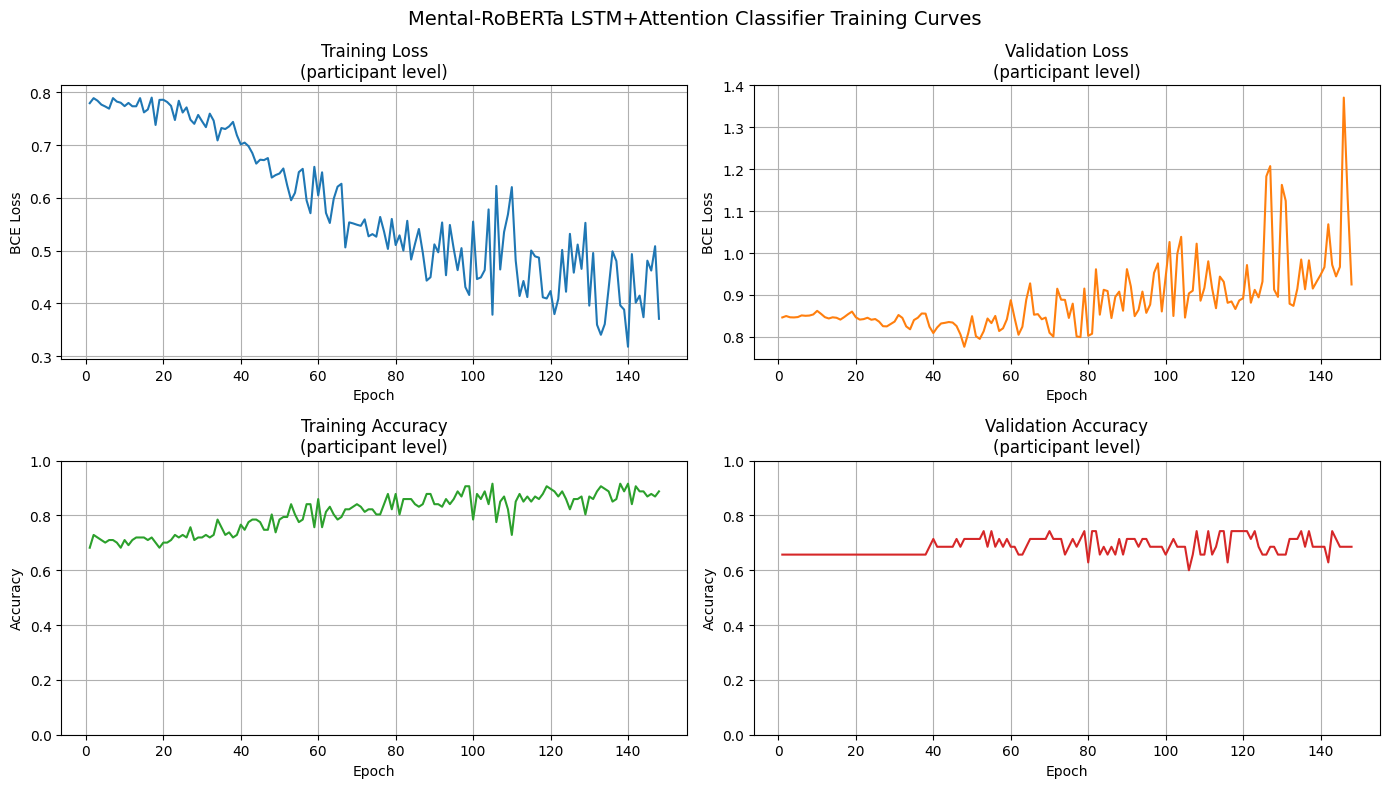

In [38]:
epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(epochs_ran, history["train_loss"], color="tab:blue")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("BCE Loss")
axes[0, 0].set_title("Training Loss\n(participant level)")
axes[0, 0].grid(True)

axes[0, 1].plot(epochs_ran, history["val_loss"], color="tab:orange")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("BCE Loss")
axes[0, 1].set_title("Validation Loss\n(participant level)")
axes[0, 1].grid(True)

axes[1, 0].plot(epochs_ran, history["train_acc"], color="tab:green")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].set_title("Training Accuracy\n(participant level)")
axes[1, 0].set_ylim(0, 1)
axes[1, 0].grid(True)

axes[1, 1].plot(epochs_ran, history["val_acc"], color="tab:red")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].set_title("Validation Accuracy\n(participant level)")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].grid(True)

plt.suptitle("Mental-RoBERTa LSTM+Attention Classifier Training Curves", fontsize=14)
plt.tight_layout()
plt.show()

## 10. Attention Weight Visualisation

Inspect which transcript chunks the model attends to for a sample of test participants.
High attention weights indicate the model found those chunks most informative for its prediction.

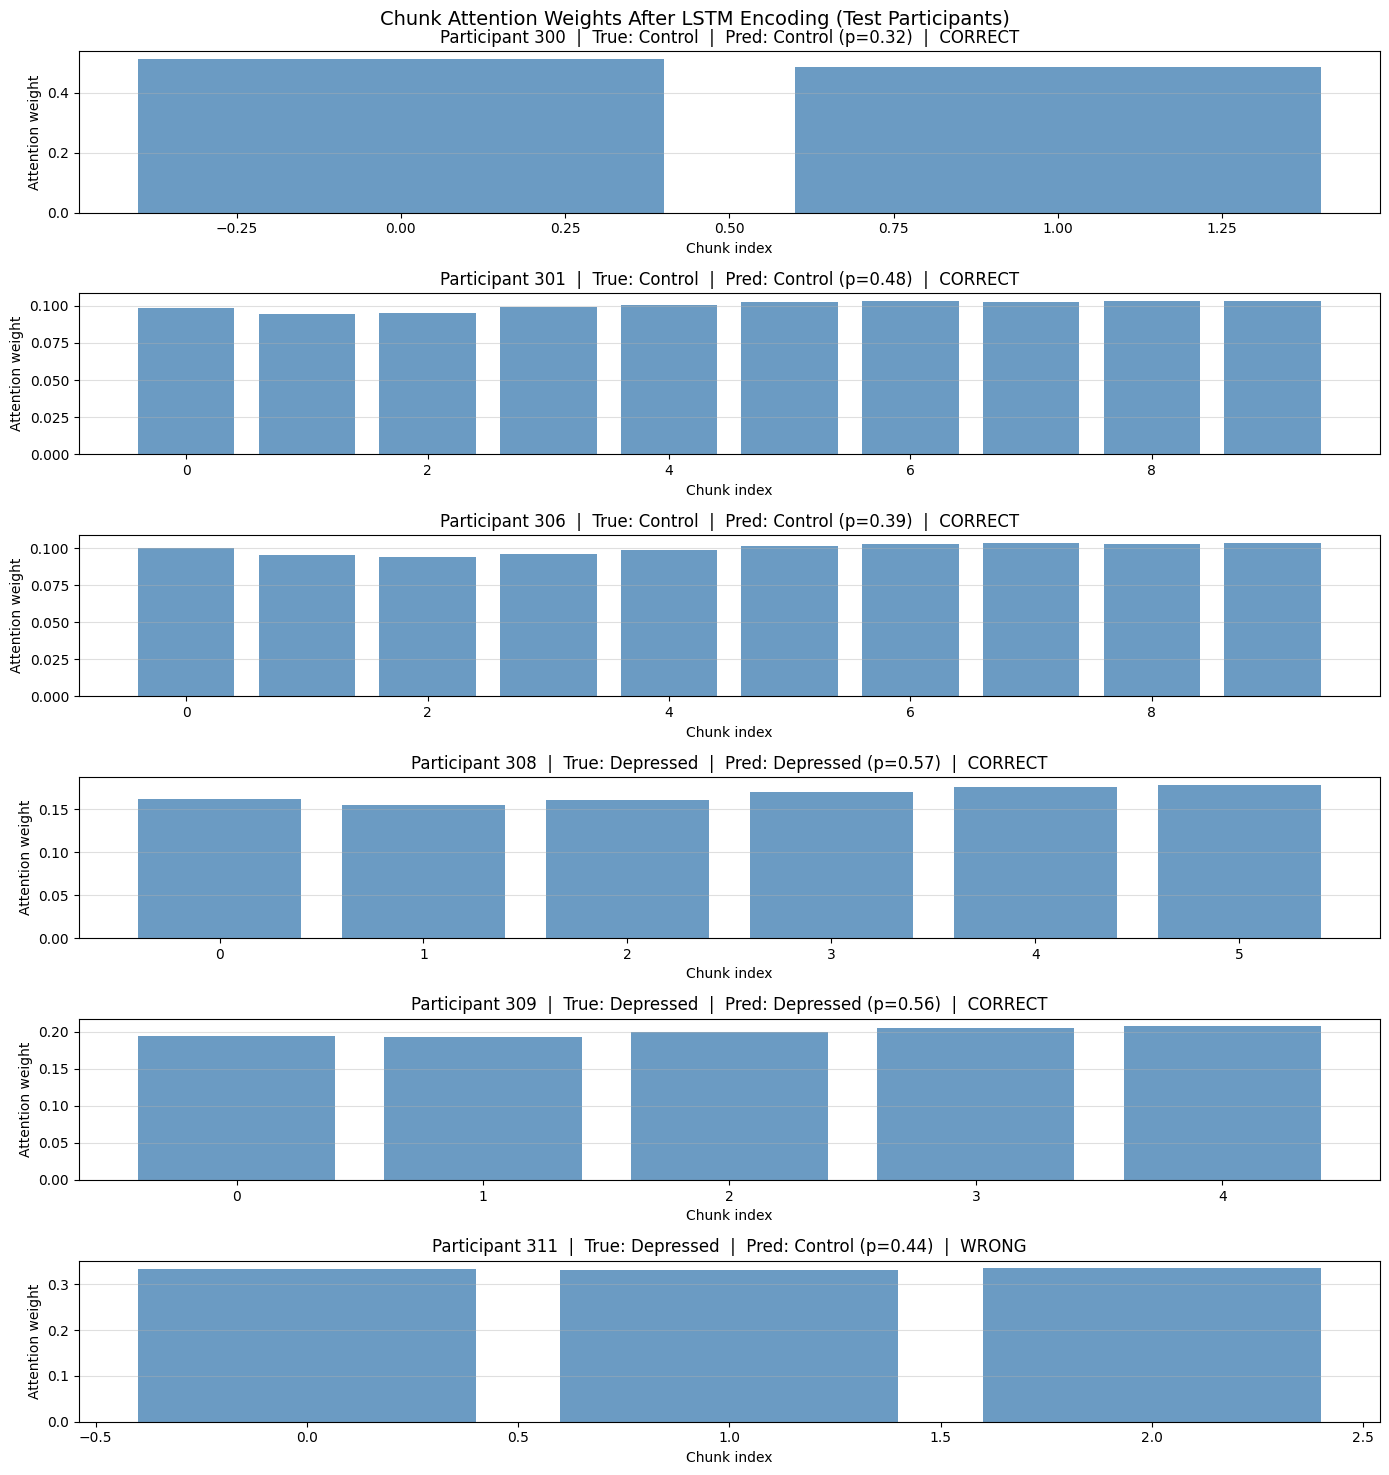

In [39]:
model.eval()
n_show = min(6, len(splits_list["test"]))
fig, axes = plt.subplots(n_show, 1, figsize=(14, 2.5 * n_show))
if n_show == 1:
    axes = [axes]

with torch.no_grad():
    for ax, (pid, data) in zip(axes, splits_list["test"][:n_show]):
        feats = torch.tensor(
            np.array(data["feats"]), dtype=torch.float32, device=DEVICE
        )
        _, attn_weights = model.get_attention_weights(feats)
        attn_weights = attn_weights.squeeze().cpu().numpy()

        logit = model(feats)
        pred_prob = torch.sigmoid(logit).item()
        pred = 1 if pred_prob >= best_thresh else 0
        true_lbl = data["label"]

        chunk_axis = np.arange(len(attn_weights))
        ax.bar(chunk_axis, attn_weights, color="steelblue", alpha=0.8)
        ax.set_xlabel("Chunk index")
        ax.set_ylabel("Attention weight")
        status = "CORRECT" if pred == true_lbl else "WRONG"
        label_str = "Depressed" if true_lbl == 1 else "Control"
        pred_str = "Depressed" if pred == 1 else "Control"
        ax.set_title(
            f"Participant {pid}  |  True: {label_str}  |  "
            f"Pred: {pred_str} (p={pred_prob:.2f})  |  {status}"
        )
        ax.grid(True, axis="y", alpha=0.4)

plt.suptitle("Chunk Attention Weights After LSTM Encoding (Test Participants)", fontsize=14)
plt.tight_layout()
plt.show()


## 11. Evaluation on Test Set

Loads the best checkpoint (lowest validation loss) and reports participant-level
**accuracy, precision, recall, and F1 score** using the validation-tuned threshold.

In [40]:
# best_ckpt and model already loaded + threshold tuned at end of training cell
_, _, test_results_df = evaluate("test", threshold=best_thresh)

y_true = test_results_df["label"].values.astype(int)
y_pred = test_results_df["pred"].values.astype(int)

test_acc  = accuracy_score(y_true, y_pred)
test_prec = precision_score(y_true, y_pred, zero_division=0)
test_rec  = recall_score(y_true, y_pred, zero_division=0)
test_f1   = f1_score(y_true, y_pred, zero_division=0)

print(f"Best checkpoint : epoch {best_ckpt['epoch']}  "
      f"(val loss {best_ckpt['val_loss']:.4f}, val acc {best_ckpt['val_acc']:.4f})")
print(f"Decision threshold: {best_thresh:.2f}  (tuned on validation macro-F1)")
print(f"\nParticipants evaluated: {len(test_results_df)}")
print()
print("Test-set results (participant level)")
print(f"  Accuracy  : {test_acc:.4f}  "
      f"({int(test_acc * len(y_true))}/{len(y_true)} correct)")
print(f"  Precision : {test_prec:.4f}")
print(f"  Recall    : {test_rec:.4f}")
print(f"  F1 Score  : {test_f1:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=["Control", "Depressed"], zero_division=0))

Best checkpoint : epoch 48  (val loss 0.7763, val acc 0.7143)
Decision threshold: 0.50  (tuned on validation macro-F1)

Participants evaluated: 47

Test-set results (participant level)
  Accuracy  : 0.7660  (36/47 correct)
  Precision : 0.5882
  Recall    : 0.7143
  F1 Score  : 0.6452

              precision    recall  f1-score   support

     Control       0.87      0.79      0.83        33
   Depressed       0.59      0.71      0.65        14

    accuracy                           0.77        47
   macro avg       0.73      0.75      0.74        47
weighted avg       0.78      0.77      0.77        47



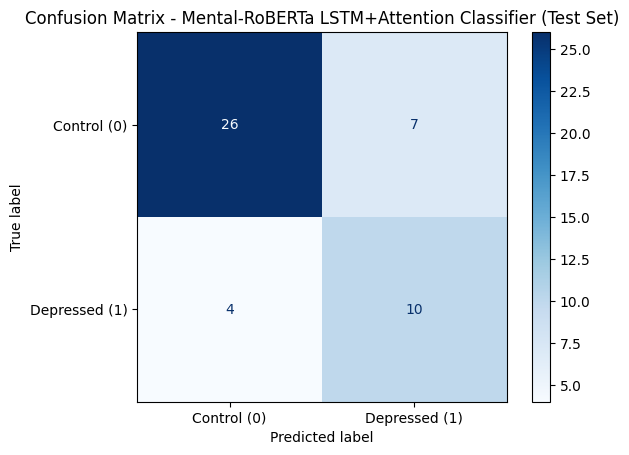

In [41]:
cm   = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Control (0)", "Depressed (1)"]
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Mental-RoBERTa LSTM+Attention Classifier (Test Set)")
plt.show()